# Introdução

O presente projeto tem como objeto de estudo uma base de dados sintética contendo transações sequenciais realizadas em um supermercado. O conjunto de dados foi criado com o objetivo de refletir comportamentos realistas de consumo ao longo do tempo, incluindo variações sazonais, promoções ocasionais e hábitos regulares de compra. Utilizando técnicas de mineração de dados, este estudo busca identificar padrões relevantes nas sequências de produtos adquiridos pelos clientes, visando entender e prever comportamentos de compra em diferentes contextos temporais. A metodologia adotada é baseada no algoritmo PrefixSpan, uma técnica amplamente reconhecida por sua eficiência na identificação de padrões sequenciais frequentes, permitindo uma análise clara e intuitiva das relações entre os itens comprados e os hábitos de consumo representados no dataset.

# Base de Dados

Para a realização do trabalho, foi utilizado um conjunto de dados sintético, criado especificamente para esta análise. Essa decisão foi baseada na dificuldade encontrada em acessar datasets reais adequados para uma exploração mais didática e aprofundada do tema. Embora existam bases de dados públicas e ferramentas especializadas, como o SPMF, os resultados obtidos frequentemente mostraram-se insuficientes. Os datasets disponíveis muitas vezes produziam padrões excessivamente simples ou pouco representativos, dificultando a interpretação e limitando o potencial didático do trabalho, que não iria ilustrar de forma satisfatória o conceito de Padrões Sequenciais. Outro problema relacionado refere-se ao fato de grande parte desses conjuntos de dados reais serem codificados, dificultando ou até impossibilitando o acesso ao significado dos items, como o nome dos produtos.

Nesse contexto, optou-se pela criação de um dataset sintético utilizando ferramentas de Inteligência Artificial Generativa, especificamente com o auxílio da ferramenta Chat GPT. Tomamos o cuidado de projetar o conjunto de dados para refletir características realistas de transações de supermercado, incluindo datas e horários variados, identificação de clientes individuais, categorias de produtos, e valores totais coerentes. Além disso, o dataset simula variações sazonais, picos em dias específicos e promoções ocasionais, permitindo uma análise mais rica e realista do comportamento de consumo.

A escolha por um dataset sintético possibilitou controlar e ajustar características específicas que seriam difíceis de garantir em datasets reais, como sequências claras e coerentes de compras para cada cliente. Isso facilitou a aplicação do algoritmo PrefixSpan, proporcionando a identificação de padrões sequenciais mais representativos e significativos. A abordagem também permitiu a exploração de padrões relacionados a produtos mais familiares e contextos de consumo cotidianos, tornando as visualizações e interpretações dos resultados mais intuitivas e acessíveis.

Há algum tempo a comunidade científica vem explorando a possibilidade dos Dados Sintéticos, dadas as suas inúmeras vantagens, desde a privacidade até o controle da qualidade e refinamento dos dados [1, 2, 3]. Atualmente, com o advento dos modelos generativos e a demanda cada vez mais alta por dados de treinamento para grande modelos, os dados sintéticos tem voltado aos holofotes das pesquisas.

## Referências

[1] Eno, J., & Thompson, C.W. (2008). Generating Synthetic Data to Match Data Mining Patterns. IEEE Internet Computing, 12.

[2] Jacobsen, B.N. (2023). Machine learning and the politics of synthetic data. Big Data & Society, 10.

[3] Qian, Z., Cebere, B., & Schaar, M.V. (2023). Synthcity: facilitating innovative use cases of synthetic data in different data modalities. ArXiv, abs/2301.07573.


# Conceitos Principais

## Complexidade e Restrições

Vamos nos referir à "complexidade" como o número crescente de condições que devem ser satisfeitas à medida que se adiciona mais itens a um padrão, enquanto "restrições" representam os requisitos que limitam a ocorrência simultânea desses itens. Por exemplo, no nosso cenário de compras de supermercado, identificar um único item como "leite" ou uma combinação simples como "pão e manteiga" é relativamente fácil, pois há poucas condições para que esses itens apareçam juntos. Entretanto, quando buscamos um padrão mais complexo, como "leite, pão, ortelã, vagem", a probabilidade de todos esses itens ocorrerem na ordem correta e no mesmo contexto diminui significativamente, devido ao aumento das restrições. Assim, padrões simples são naturalmente mais frequentes, enquanto padrões mais longos, que exigem a concordância de múltiplos elementos juntos, tendem a ter suporte menor.

## Itemsets

Um itemset é um conjunto de itens que ocorrem simultaneamente em uma única transação. No nosso contexto, um itemset representa os produtos que um cliente comprou juntos em uma única visita à loja. Por exemplo, se um cliente compra pão, leite e ovos na mesma compra, o itemset é {pão, leite, ovos}. Na análise de padrões frequentes, um itemset pode conter um único item ou múltiplos itens, o importante é ser uma compra isolada. O objetivo de identificar itemsets frequentes é descobrir quais conjuntos de itens são mais frequentemente adquiridos juntos pelos clientes, permitindo, por exemplo, entender os hábitos de consumo.

Ao unir vários itemsets de um mês, estamos avaliando também os hábitos de consumo de forma mais complexa ainda, verificando se existem ligações entre itemsets de compras.

In [ ]:
#@title Instalação de dependências

%pip install prefixspan -q


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


In [ ]:
#@title Configuração e Pré-processamento do Conjunto de Dados

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prefixspan import PrefixSpan
from collections import Counter
from datetime import timedelta
import warnings
warnings.filterwarnings("ignore")

# Ler o CSV
df = pd.read_csv('transacoes_supermercado_sintetico.csv')

# Converter datas
df['data_hora'] = pd.to_datetime(df['data_hora'], format='%Y-%m-%d %H:%M')

# Ordenar por cliente e data
df = df.sort_values(['id_cliente', 'data_hora'])

# Criar sequências (lista de itemsets) por cliente
def build_sequence(group):
    return group['lista_produtos'].apply(lambda s: tuple(s.split(';'))).tolist()

df_sequences = df.groupby('id_cliente', group_keys=False).apply(build_sequence)
sequences = df_sequences.tolist()

print("Pré-processamento concluído!")


Pré-processamento concluído!


In [ ]:
#@title Estatísticas do dataset

# 1. Dimensões e informações gerais
print("Dimensões do dataset:", df.shape)
print("Número de clientes únicos:", df['id_cliente'].nunique())

# 2. Análise da coluna 'lista_produtos'
df['num_produtos'] = df['lista_produtos'].apply(lambda s: len(s.split(';')))
print("\nEstatísticas do número de produtos por transação:")
print(df['num_produtos'].describe())

# Contagem e frequência dos produtos em todas as transações
all_products = df['lista_produtos'].str.split(';').explode()
unique_products = all_products.unique()
print("\nNúmero de produtos únicos:", len(unique_products))
print("\nTop 10 produtos mais frequentes:")
print(all_products.value_counts().head(10))

# 3. Análise temporal: Distribuição de transações ao longo do tempo
df['mes'] = df['data_hora'].dt.to_period('M')
transacoes_por_mes = df.groupby('mes').size()
print("\nNúmero de transações por mês:")
print(transacoes_por_mes)

# Se houver coluna 'valor_total', analisar estatísticas das vendas
if 'valor_total' in df.columns:
    print("\nEstatísticas do valor total das transações:")
    print(df['valor_total'].describe())
else:
    print("\nColuna 'valor_total' não encontrada no dataset.")


Dimensões do dataset: (19925, 8)
Número de clientes únicos: 200

Estatísticas do número de produtos por transação:
count    19925.000000
mean         5.312923
std          2.784179
min          1.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         16.000000
Name: num_produtos, dtype: float64

Número de produtos únicos: 62

Top 10 produtos mais frequentes:
lista_produtos
Pizza Congelada         3373
Lasanha Congelada       3361
Hambúrguer Congelado    3311
Amendoim                2516
Biscoito Recheado       2418
Linguiça                2219
Feijão                  2143
Óleo de Soja            2120
Pão de Forma            2110
Escova de Dentes        2075
Name: count, dtype: int64

Número de transações por mês:
mes
2024-01    1638
2024-02    1512
2024-03    1706
2024-04    1564
2024-05    1653
2024-06    1640
2024-07    1605
2024-08    1786
2024-09    1602
2024-10    1621
2024-11    1665
2024-12    1933
Freq: M, dtype: int64

Estatísticas do valor total 

In [ ]:
#@title Aplicação do Algoritmo PrefixSpan


min_support_count = 5 # @param {"type":"number"}
# @markdown Essa variável define o suporte mínimo para o algoritmo PrefixSpan, ou seja, o número mínimo de vezes que um padrão precisa aparecer no conjunto de sequências para ser considerado "frequente", ou seja, relevante.

# Extrair padrões com PrefixSpan
ps = PrefixSpan(sequences)

patterns = ps.frequent(min_support_count)
patterns.sort(key=lambda x: x[0], reverse=True)

# Converter a lista de padrões para um DataFrame para facilitar as visualizações
df_patterns = pd.DataFrame(patterns, columns=['support', 'pattern'])
df_patterns['pattern_length'] = df_patterns['pattern'].apply(len)

print("Extração de padrões concluída!")
print(df_patterns.head())


Extração de padrões concluída!
   support                                            pattern  pattern_length
0      114  [(Hambúrguer Congelado, Lasanha Congelada, Piz...               1
1       52                               [(Pizza Congelada,)]               1
2       49        [(Hambúrguer Congelado, Lasanha Congelada)]               1
3       48             [(Lasanha Congelada, Pizza Congelada)]               1
4       42                             [(Lasanha Congelada,)]               1


# Gráficos

## Gráfico 001 - Comprimento vs Padrões

Este gráfico exibe a quantidade de padrões para cada comprimento (número de itens ou itemsets que compõem o padrão). Dessa forma, podemos verificar se existem mais padrões com apenas 1 item, 2 itens, 3 itens, etc. Esse tipo de visualização ajuda a entender como os padrões se distribuem no sentido de complexidade.

Interpretação do gráfico:

Observa-se que a maior parte dos padrões possui 2 itens, seguida pelos de 1 item. Já padrões com 3 ou mais itens são menos frequentes.
Isso indica que a maioria das combinações relevantes (no sentido de suporte) envolve poucos itens.

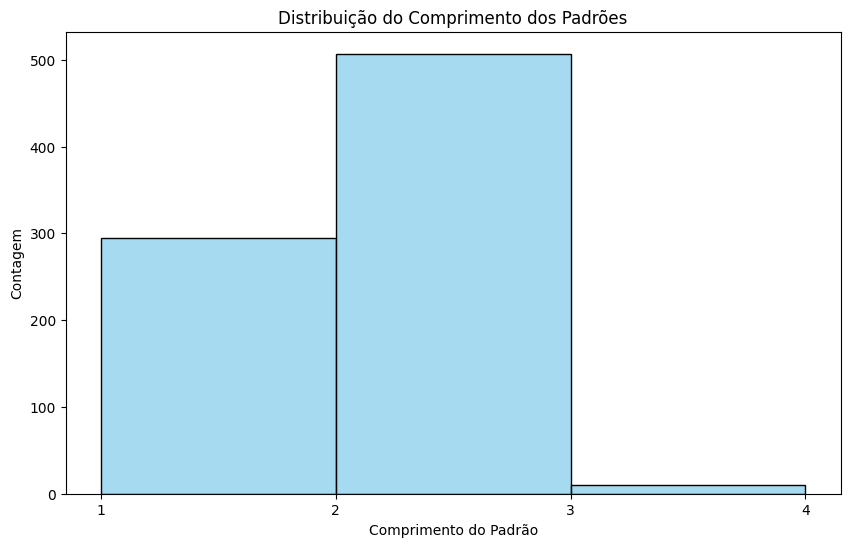

In [ ]:
#@title Código do Gráfico 001

plt.figure(figsize=(10, 6))
bins = range(1, df_patterns['pattern_length'].max() + 2)
sns.histplot(df_patterns['pattern_length'], bins=bins, kde=False, color='skyblue')
plt.title('Distribuição do Comprimento dos Padrões')
plt.xlabel('Comprimento do Padrão')
plt.ylabel('Contagem')
plt.xticks(bins)
plt.show()


## Gráfico 002 - Distribuição do Suporte dos Padrões

Este gráfico mostra como o suporte (frequência de ocorrência) está distribuído entre todos os padrões descobertos. O suporte representa quantas vezes cada padrão aparece no conjunto de dados. Assim, podemos identificar se há muitos padrões com suporte baixo e poucos com suporte muito alto ou vice-versa.

Interpretação do gráfico:

- A maior parte dos padrões se concentra em suportes mais baixos, perto do mínimo definido.
- Há alguns padrões com suporte relativamente maior, o que forma uma "cauda longa" ¹ na direita do gráfico.


---


¹ No contexto de estratégia de mercado, a cauda longa consiste em vender uma grande variedade de itens, mesmo em pequenas quantidades, para atender a um nicho e se diferenciar da concorrência. No gráfico, as sequências menos comuns podem representar uma oportunidade de adotar esta estratégia.

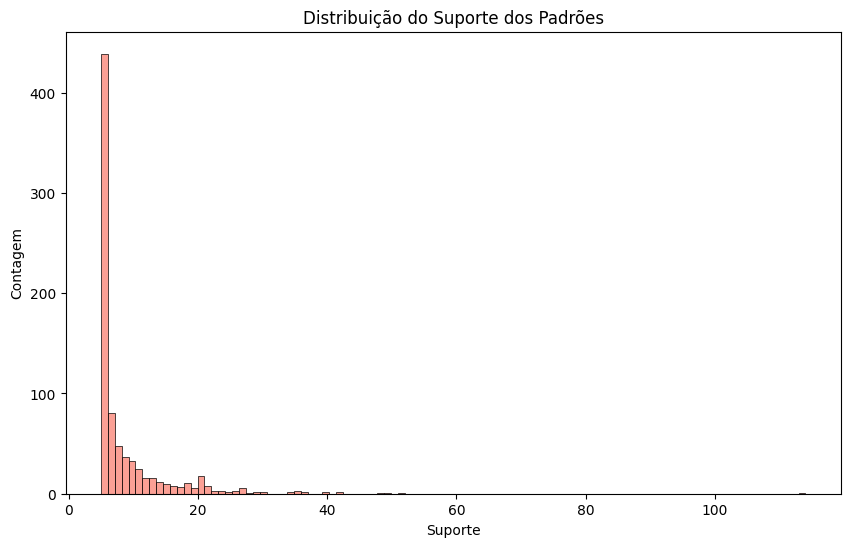

In [ ]:
#@title Código do Gráfico 002

plt.figure(figsize=(10, 6))
sns.histplot(df_patterns['support'], color='salmon')
plt.title('Distribuição do Suporte dos Padrões')
plt.xlabel('Suporte')
plt.ylabel('Contagem')
plt.show()


## Gráfico 0003 - Relação entre Comprimento do Padrão e Suporte

Neste gr;afico, cada ponto representa um padrão. No eixo X temos o comprimento do padrão (quantidade de itens) e, no eixo Y, o suporte (quantidade de ocorrências). O objetivo é visualizar se padrões mais longos tendem a ter suportes maiores ou menores, e como se distribuem os valores de suporte em cada comprimento.

Interpretação do gráfico:

- Os padrões de 1 item aparecem em maior quantidade e, em alguns casos, atingem suportes mais altos.
- À medida que o comprimento do padrão aumenta (2, 3 itens), observa-se geralmente um suporte menor, como discutida anteriormente a questão da complexidade e restrição.


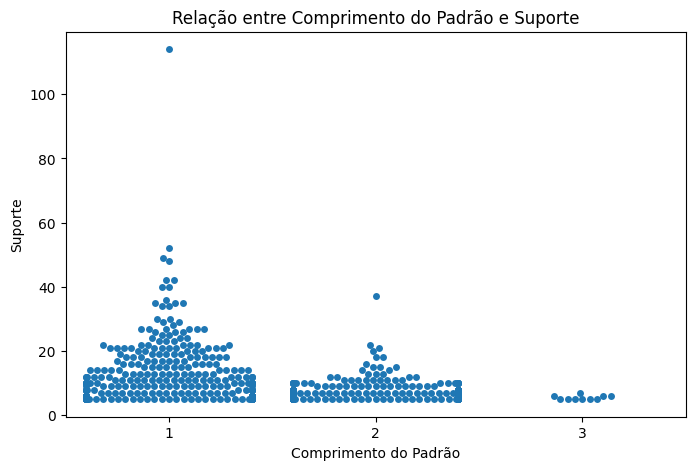

,count
pattern_length,
2,507
1,295
3,10


In [ ]:
#@title Código do Gráfico 003

plt.figure(figsize=(8,5))
sns.swarmplot(x='pattern_length', y='support', data=df_patterns)
plt.title('Relação entre Comprimento do Padrão e Suporte')
plt.xlabel('Comprimento do Padrão')
plt.ylabel('Suporte')
plt.show()

df_patterns.pattern_length.value_counts()


## Gráfico 004 - Top 10 Padrões com Maior Suporte

Este gráfico apresenta os 10 padrões com maior suporte, aqueles que mais se repetem no conjunto de dados. Cada barra representa um padrão, enquanto o comprimento da barra indica quantas vezes esse padrão ocorre.

Interpretação do gráfico:

- A maioria dos principais padrões (9 de 10) é formada por itemsets únicos, o que corrobora a ideia de que padrões menos complexos tendem a ser mais comums estatísticamente.
- Alguns items são claramente preferenciais como os congelados.

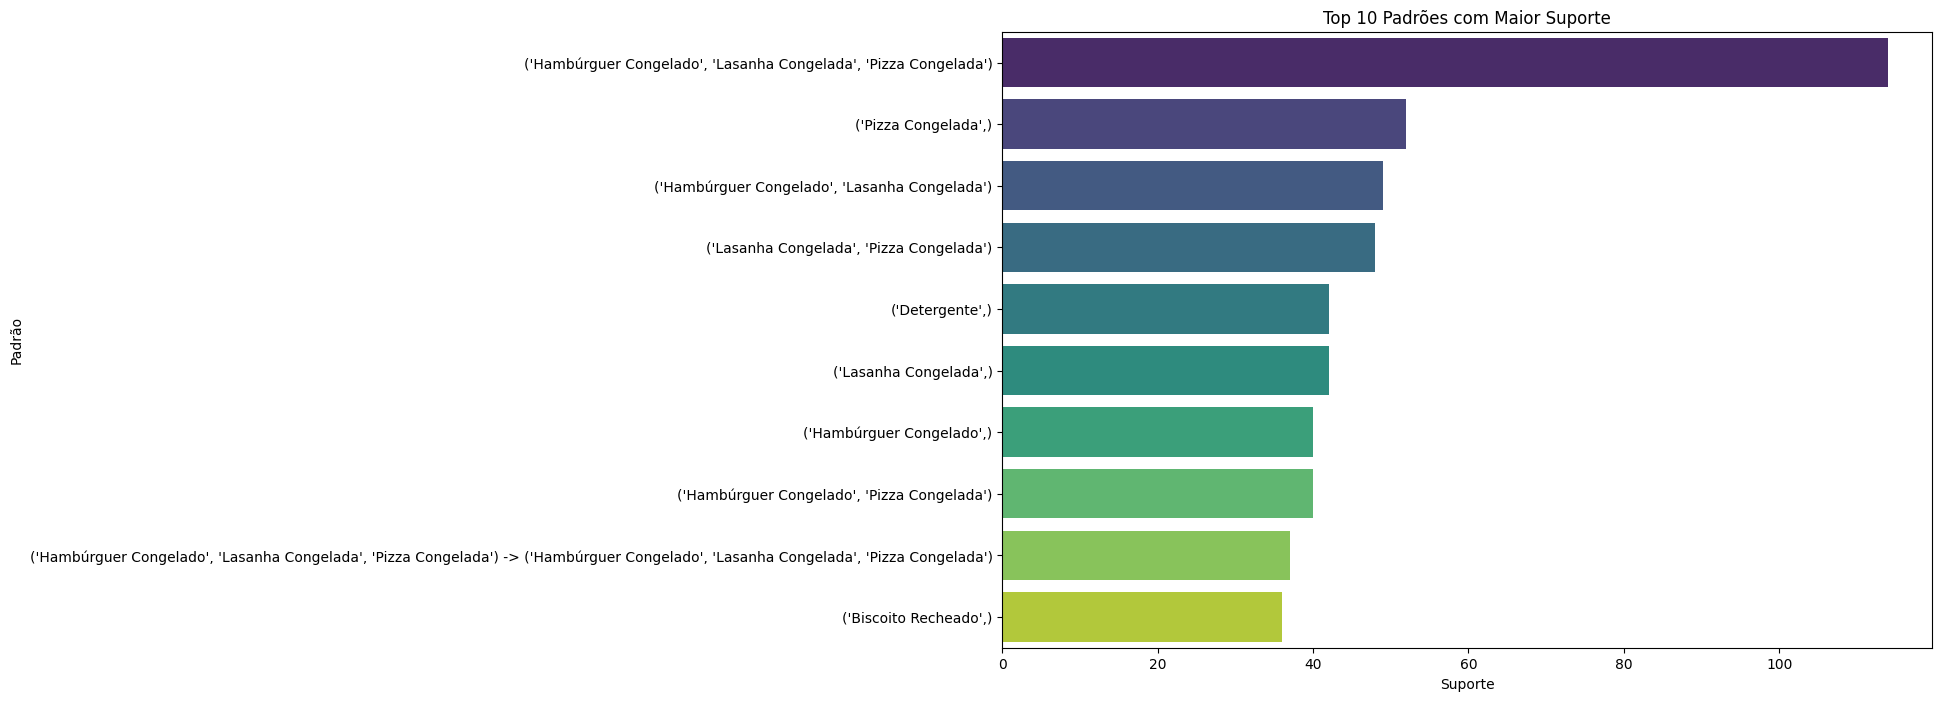

In [ ]:
#@title Código do Gráfico 004

df_top = df_patterns.sort_values(by='support', ascending=False).head(10).copy()
df_top['pattern_str'] = df_top['pattern'].apply(lambda x: ' -> '.join(map(str, x)))
plt.figure(figsize=(12, 8))
sns.barplot(x='support', y='pattern_str', data=df_top, palette='viridis')
plt.title('Top 10 Padrões com Maior Suporte')
plt.xlabel('Suporte')
plt.ylabel('Padrão')
plt.show()


## Gráfico 005 - Top 15 Itens Mais Frequentes nos Padrões

Neste gráfico, analisamos os itens individualmente, mostrando quais itemsets de produtos aparecem com mais frequência dentro de todos os padrões. Assim, temos uma visão mais de perto de quais itens são mais recorrentes nas combinações frequentes.

Interpretação do gráfico:

- É um gráfico interessante pois permite identificar facilmente os itens que mais contribuem para a formação de padrões frequentes.
- Essa visualização de items mais frequentes poderia ajudar ao supermercado, por exemplo, no planejamento de estoque e priorização de produtos no futuro.


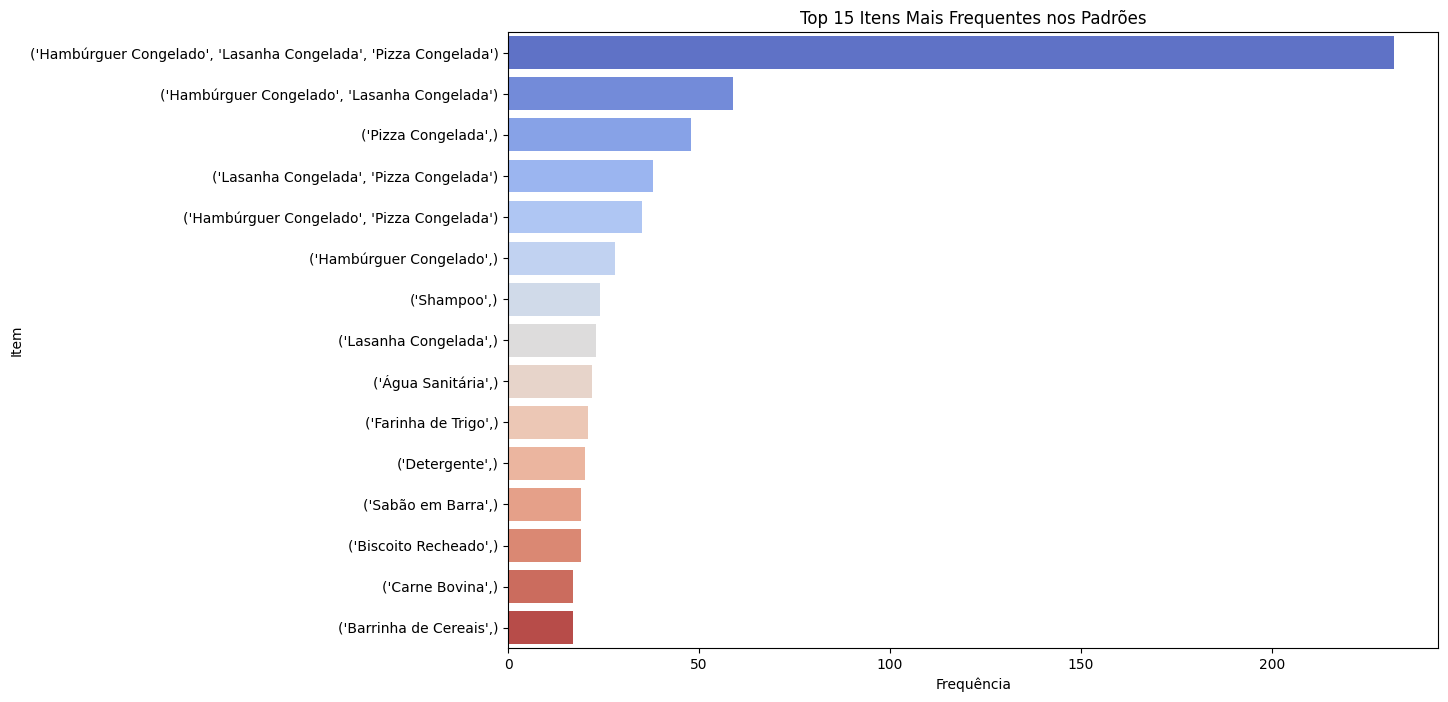

In [ ]:
#@title Código do Gráfico 005

# Calcular a frequência dos itens nos padrões
all_items = []
for support, pattern in patterns:
    all_items.extend(pattern)
counter = Counter(all_items)
# Converter as chaves para string para evitar problemas com MultiIndex
data = [(str(item), freq) for item, freq in counter.items()]
df_counter = pd.DataFrame(data, columns=['item', 'frequency'])
df_counter = df_counter.sort_values(by='frequency', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='frequency', y='item', data=df_counter.head(15), palette='coolwarm')
plt.title('Top 15 Itens Mais Frequentes nos Padrões')
plt.xlabel('Frequência')
plt.ylabel('Item')
plt.show()


In [ ]:
#@title Código de preparação da série temporal

# Preparar a série temporal de faturamento diário
df['data'] = df['data_hora'].dt.date
df_diario = df.groupby('data')['valor_total'].sum().reset_index(name='faturamento_diario')
df_diario = df_diario.sort_values('data')

# Função auxiliar para verificar se uma sequência contém um padrão
def _sequence_contains(seq, pattern):
    idx = 0
    for itemset in seq:
        if itemset == pattern[idx]:
            idx += 1
            if idx == len(pattern):
                return True
    return False

# Função para identificar os dias em que o padrão ocorreu
def pattern_occurrence_days(pattern, df, df_sequences):
    days = []
    for client in df_sequences.index:
        seq = df_sequences[client]
        if _sequence_contains(seq, pattern):
            # Pega a data/hora da última transação do cliente (simplificação)
            dt_final = df[df['id_cliente'] == client]['data_hora'].max()
            days.append(dt_final.date())
    return days

print("Preparação da série temporal concluída!")


Preparação da série temporal concluída!


## Gráfico 006 - Série Temporal + Ocorrências de um Padrão Específico

Este gráfico mostra a evolução do faturamento diário ao longo do tempo (linha azul) e destaca, em pontos vermelhos, os dias em que determinado padrão (no exemplo, o padrão de maior suporte) foi encontrado. O objetivo é verificar se a ocorrência desse padrão coincide com possíveis picos de vendas ou outras variações no faturamento.

Interpretação do gráfico:

Observando os pontos vermelhos, é possível perceber se a presença do padrão em certas datas coincide com altas ou baixas no faturamento.
Se existir uma correlação clara (por exemplo, quando o padrão ocorre, o faturamento aumenta), isso pode indicar oportunidades de promoção, divulgação ou até otimizar o estoque.
Caso não haja correlação aparente, o padrão pode ser frequente, mas não necessariamente influenciar diretamente as vendas do dia.


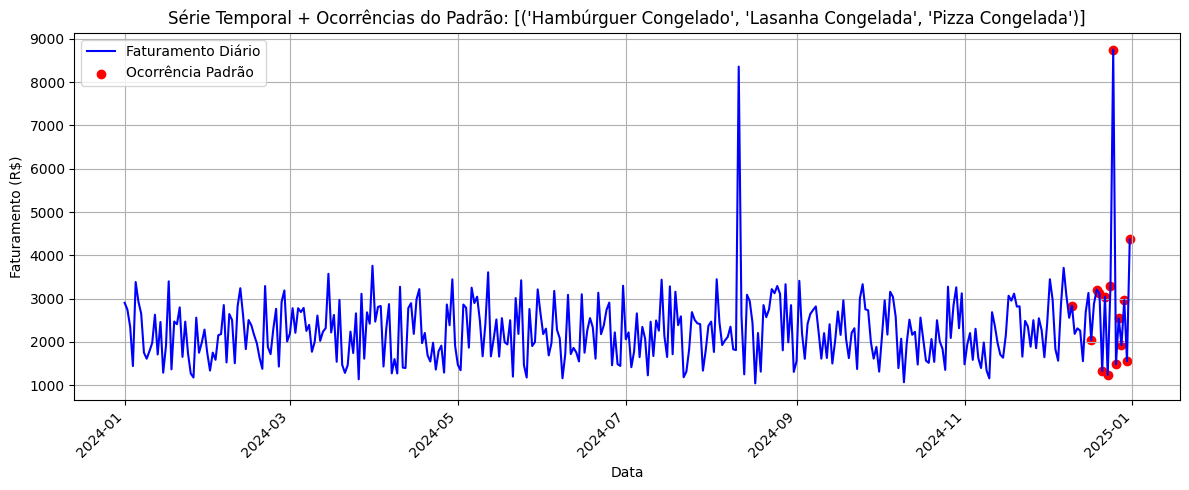

In [ ]:
#@title Código do Gráfico 006

# Escolher o top padrão (o de maior suporte)
if patterns:
    top_pattern = patterns[0][1]  # Pega o padrão com maior suporte

    fig, ax = plt.subplots(figsize=(12, 5))
    df_diario['data_dt'] = pd.to_datetime(df_diario['data'])
    ax.plot(df_diario['data_dt'], df_diario['faturamento_diario'], color='blue', label='Faturamento Diário')

    # Marcar os dias em que o padrão ocorreu
    days_pattern = pattern_occurrence_days(top_pattern, df, df_sequences)
    days_unique = list(set(days_pattern))
    days_unique = pd.to_datetime(days_unique)
    df_mark = df_diario[df_diario['data_dt'].isin(days_unique)]
    ax.scatter(df_mark['data_dt'], df_mark['faturamento_diario'], color='red', label='Ocorrência Padrão')

    ax.set_title(f"Série Temporal + Ocorrências do Padrão: {top_pattern}")
    ax.set_xlabel("Data")
    ax.set_ylabel("Faturamento (R$)")
    ax.legend()
    ax.grid(True)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## Gráfico 007 - Como a compra de um produto afeta a compra do seguinte

Este gráfico mostra como um item leva a outro em transações consecutivas. No eixo vertical (linhas) temos o item anterior, enquanto no eixo horizontal (colunas) está o item subsequente. Cada célula indica o número de vezes que o item da linha foi imediatamente seguido pelo item da coluna. Assim, podemos identificar, por exemplo, se comprar "Pizza Congelada" costuma ser seguido pela compra de “Hambúrguer Congelado”, ou se a compra de "Leite" é comumente seguida por "Café".

Interpretação do gráfico:

As células com valores mais altos (tons mais escuros) representam transições mais frequentes entre dois itens, ou seja, combinações ou sequências de compra que aparecem várias onde um é seguido do outro.

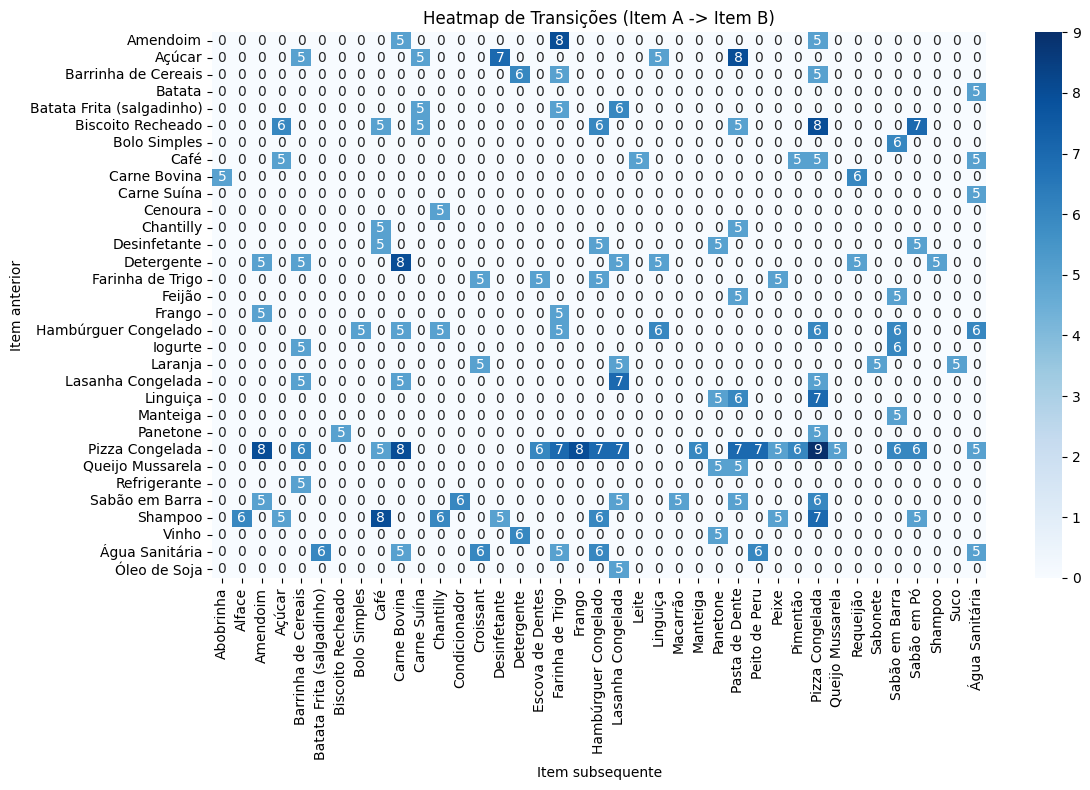

In [ ]:
#@title Código do Gráfico 007

# 1) Filtrar padrões para considerar apenas transições de 1 item -> 1 item
filtered_patterns = []
for support, pattern in patterns:
    # Verifica se o padrão tem exatamente 2 itemsets
    # e se cada itemset contém exatamente 1 item
    if len(pattern) == 2 and len(pattern[0]) == 1 and len(pattern[1]) == 1:
        filtered_patterns.append((support, pattern))

# 2) Criar um DataFrame com colunas: item_from, item_to, support
transitions_data = []
for support, pattern in filtered_patterns:
    item_from = pattern[0][0]
    item_to = pattern[1][0]
    transitions_data.append((item_from, item_to, support))

df_transitions = pd.DataFrame(transitions_data, columns=['item_from', 'item_to', 'support'])

# 3) Somar suportes de transições iguais (caso haja duplicadas)
df_transitions_agg = (
    df_transitions
    .groupby(['item_from','item_to'], as_index=False)['support']
    .sum()
)

# 4) Criar a matriz (pivot) e preencher valores ausentes com zero
df_matrix = df_transitions_agg.pivot(
    index='item_from',
    columns='item_to',
    values='support'
).fillna(0)

# 5) Plotar o Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_matrix, cmap='Blues', annot=True, fmt='.0f')
plt.title("Heatmap de Transições (Item A -> Item B)")
plt.xlabel("Item subsequente")
plt.ylabel("Item anterior")
plt.tight_layout()
plt.show()
